In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [2]:
import pandas as pd
import numpy as np
from tensorflow.keras import utils # utils.to_categorical()
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 로직스틱회귀분석(이진분류)
## 1. 데이터 셋 생성 및 전처리

In [8]:
# 1. csv파일을 데이터프레임으로 읽어오기(결측치처리, 타겟변수 균형확인) => 넘파이 배열로 변환 => 데이터분할
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
# 1. 임신횟수
# 2. 2시간내 포도당 농도
# 3. 혈압
# 4. 피부접힘 두께
# 5. 인슐린수치
# 6. BMI체질량지수
# 7. 가족력
# 8. 나이
# 9. 당뇨병발병여부
df.sample()

,0,1,2,3,4,5,6,7,8
430,2,99,0,0,0,22.2,0.108,23,0


In [9]:
df.shape

(768, 9)

In [10]:
df.info() # 결측치 없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
df.isna().sum() # 열별 결측치 갯수

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [15]:
# 타겟변수의 균형 확인
df[8].value_counts()/len(df)

0    0.651042
1    0.348958
Name: 8, dtype: float64

In [19]:
# np.array(df)
dataset = df.values
dataset = df.to_numpy()

In [23]:
# 2. csv파일을 넘파이배열 읽어오기 => 데이터 분할
    # np.loadtxt()
dataset = np.loadtxt('data/pima-indians-diabetes.csv', 
                     encoding='utf-8',
                     delimiter=',',
                    # comments='#'
                    )
dataset.shape

(768, 9)

In [24]:
# 데이터 분할 : 학습데이터셋(모델학습용) + 시험데이터셋(모델평가용)
X_train = dataset[:620, :-1]
y_train = dataset[:620, -1]
X_test  = dataset[620:, :-1]
y_test  = dataset[620:, -1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((620, 8), (620,), (148, 8), (148,))

## 2. 모델 구성

In [32]:
model = Sequential()
# model.add(Dense(64, 
#                 input_dim=8, #input_shape=(8,), 
#                 activation='relu'))
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) # 로지스틱회귀분석의 출력층 활성화함수
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 32)                288       
                                                                 
 dense_8 (Dense)             (None, 64)                2112      
                                                                 
 dense_9 (Dense)             (None, 16)                1040      
                                                                 
 dense_10 (Dense)            (None, 1)                 17        
                                                                 
Total params: 3,457
Trainable params: 3,457
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [33]:
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
# accuracy가 자동적으로 binary_accuracy 적용
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## 4. 학습

In [34]:
%%time
hist = model.fit(X_train, y_train, # 훈련(학습)데이터셋
                epochs=200,
                batch_size=310,
                # validation_data=(X_val, y_val)  검증데이터셋
                validation_split=0.1, # 검증데이터비율(훈련데이터셋에서 10%는 검증데이터셋으로) 
                verbose=0) # 학습과정 로그 출력 안 함

CPU times: total: 7.52 s
Wall time: 6.41 s


## 5. 모델 평가하기
- 학습과정 시각화하여 살펴보기
- 평가(시험데이터셋)
- 교차표(혼동행렬, 성능평가지표) 그리기

In [30]:
hist.history.keys() 

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

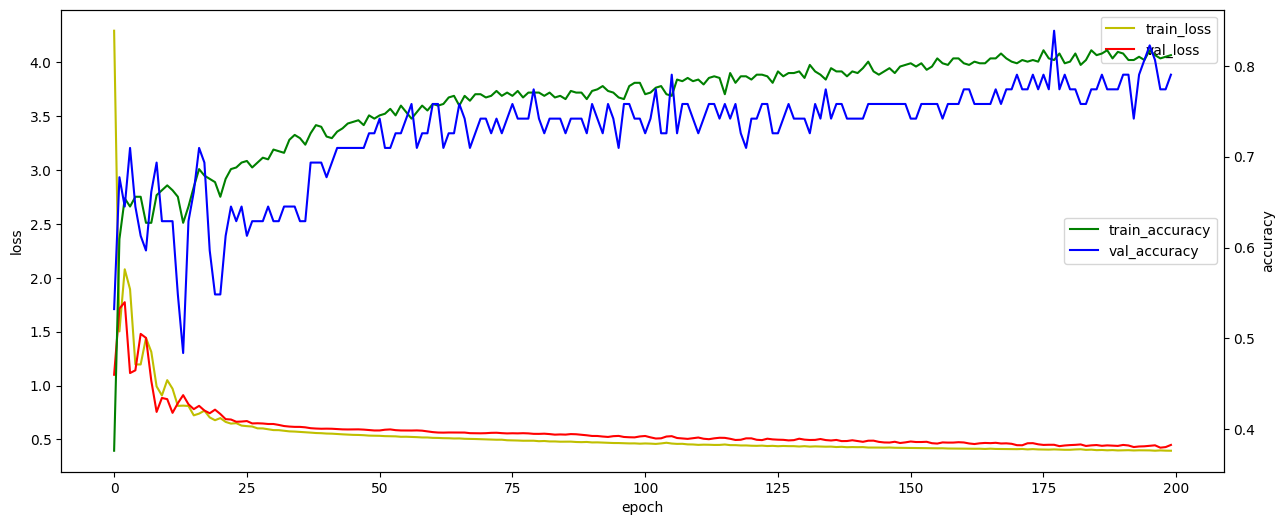

In [35]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [37]:
# 모델 평가(X)
model.evaluate(X_train, y_train, 
              # batch_size=310
              )

20/20 [==============================] - 0s 4ms/step - loss: 0.4001 - accuracy: 0.8129


[0.4001457989215851, 0.8129032254219055]

In [42]:
# 모델 평가(O)
loss, accuracy = model.evaluate(X_test, y_test)
print(f'정확도 : {accuracy*100:.2f}%')

5/5 [==============================] - 0s 5ms/step - loss: 0.5874 - accuracy: 0.7230
정확도 : 72.30%


In [49]:
# 교차표(혼동행렬, 성능평가지표)
y_hat = (model.predict(X_test)>0.5).astype(int)
# y_test : 1차원
# y_hat : 2차원

5/5 [==============================] - 0s 2ms/step


In [52]:
TN=0; FP=0; FN=0; TP=0
for y, h in zip(y_test, y_hat.reshape(-1)):
    # print(y, h)
    if y==0 and h==0:
        TN += 1 
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, FP)
print(FN, TP)

81 15
26 26


In [61]:
ctab = pd.crosstab(y_test.astype(int), # 실제값
           y_hat.reshape(-1)) # 예측값
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
pd.crosstab(y_test.astype(int),
           y_hat.reshape(-1),
           rownames=['실제값'],
           colnames=['예측값']) # 결과가 데이터프레임인 교차표

예측값,0,1
실제값,,
0,81,15
1,26,26


In [62]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat) # 결과가 numpy배열인 혼동행렬

array([[81, 15],
       [26, 26]], dtype=int64)

In [64]:
precision = 26 / (15+26)
recall = 26 / (26+26)
print('recall :',recall)
print('precision :', precision)

recall : 0.5
precision : 0.6341463414634146


## 6. 모델 사용(예측, 저장)

In [69]:
# 모델 저장
from tensorflow.keras.models import save_model, load_model
model.save('model/05_pima.h5')
save_model(model, 'model/05_pima.h5')

In [70]:
# 저장한 모델 load
model2 = load_model('model/05_pima.h5')

In [78]:
X_test[0], y_test[0]

(array([  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
         28.   ]),
 0.0)

In [76]:
# 예측하기
(model.predict([[2,112, 86, 42, 160, 38.4,0.246,28]])>0.5).astype(int)

1/1 [==============================] - 0s 34ms/step


0

In [77]:
(model.predict([[2,112, 86, 42, 160, 38.4,0.246,28],
               [6,148,72,35,0,33.6,0.627,50]
               ])>0.5).astype(int)

1/1 [==============================] - 0s 33ms/step


array([[0],
       [0]])

# 분류분석
- 1. 데이터 생성 및 전처리 : 훈련셋600, 검증셋100, 테스트셋68로 분리. 타겟변수의 원핫인코딩
- 2. 모델 생성(input8, output2)- 출력층의 활성화함수 softmax
- 3. 모델학습과정 loss='categorical_crossentropy' metrics=['accuracy']
- 4. 모델학습 validation_data = (X_val, y_val)
- 5. 모델학습평가
- 6. 모델사용  model.predict(input_data).argmax()

## 1. 데이터셋 생성 및 전처리